### model_training--User Return Prediction
I solved a problem for startup compony website. it will help alot to find out the user behavior. then compony esay to make the dicision . how to sale our product using user behaavior. and what kind of user visit in our website.

In [2]:
import seaborn as sns
import numpy as  np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.preprocessing import FunctionTransformer


In [3]:
df = pd.read_csv("../data/gold/feature_data.csv")
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Avg Time Per Page,Timespend,Return
0,5,11.051381,0.230652,Organic,3.890460,0.778092,14.941841,1
1,4,3.429316,0.391001,Social,8.478174,2.119544,11.907490,0
2,4,1.621052,0.397986,Organic,9.636170,2.409042,11.257222,1
3,5,3.629279,0.180458,Organic,2.071925,0.414385,5.701204,1
4,5,4.235843,0.291541,Paid,1.960654,0.392131,6.196497,1


<Axes: xlabel='Session Duration', ylabel='Time on Page'>

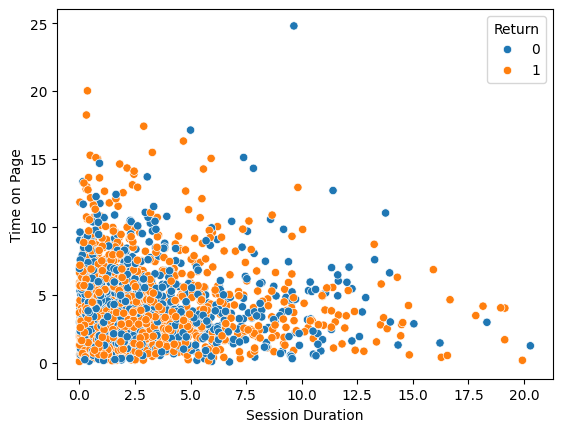

In [4]:
sns.scatterplot(x=df['Session Duration'], y=df['Time on Page'], hue=df['Return'])

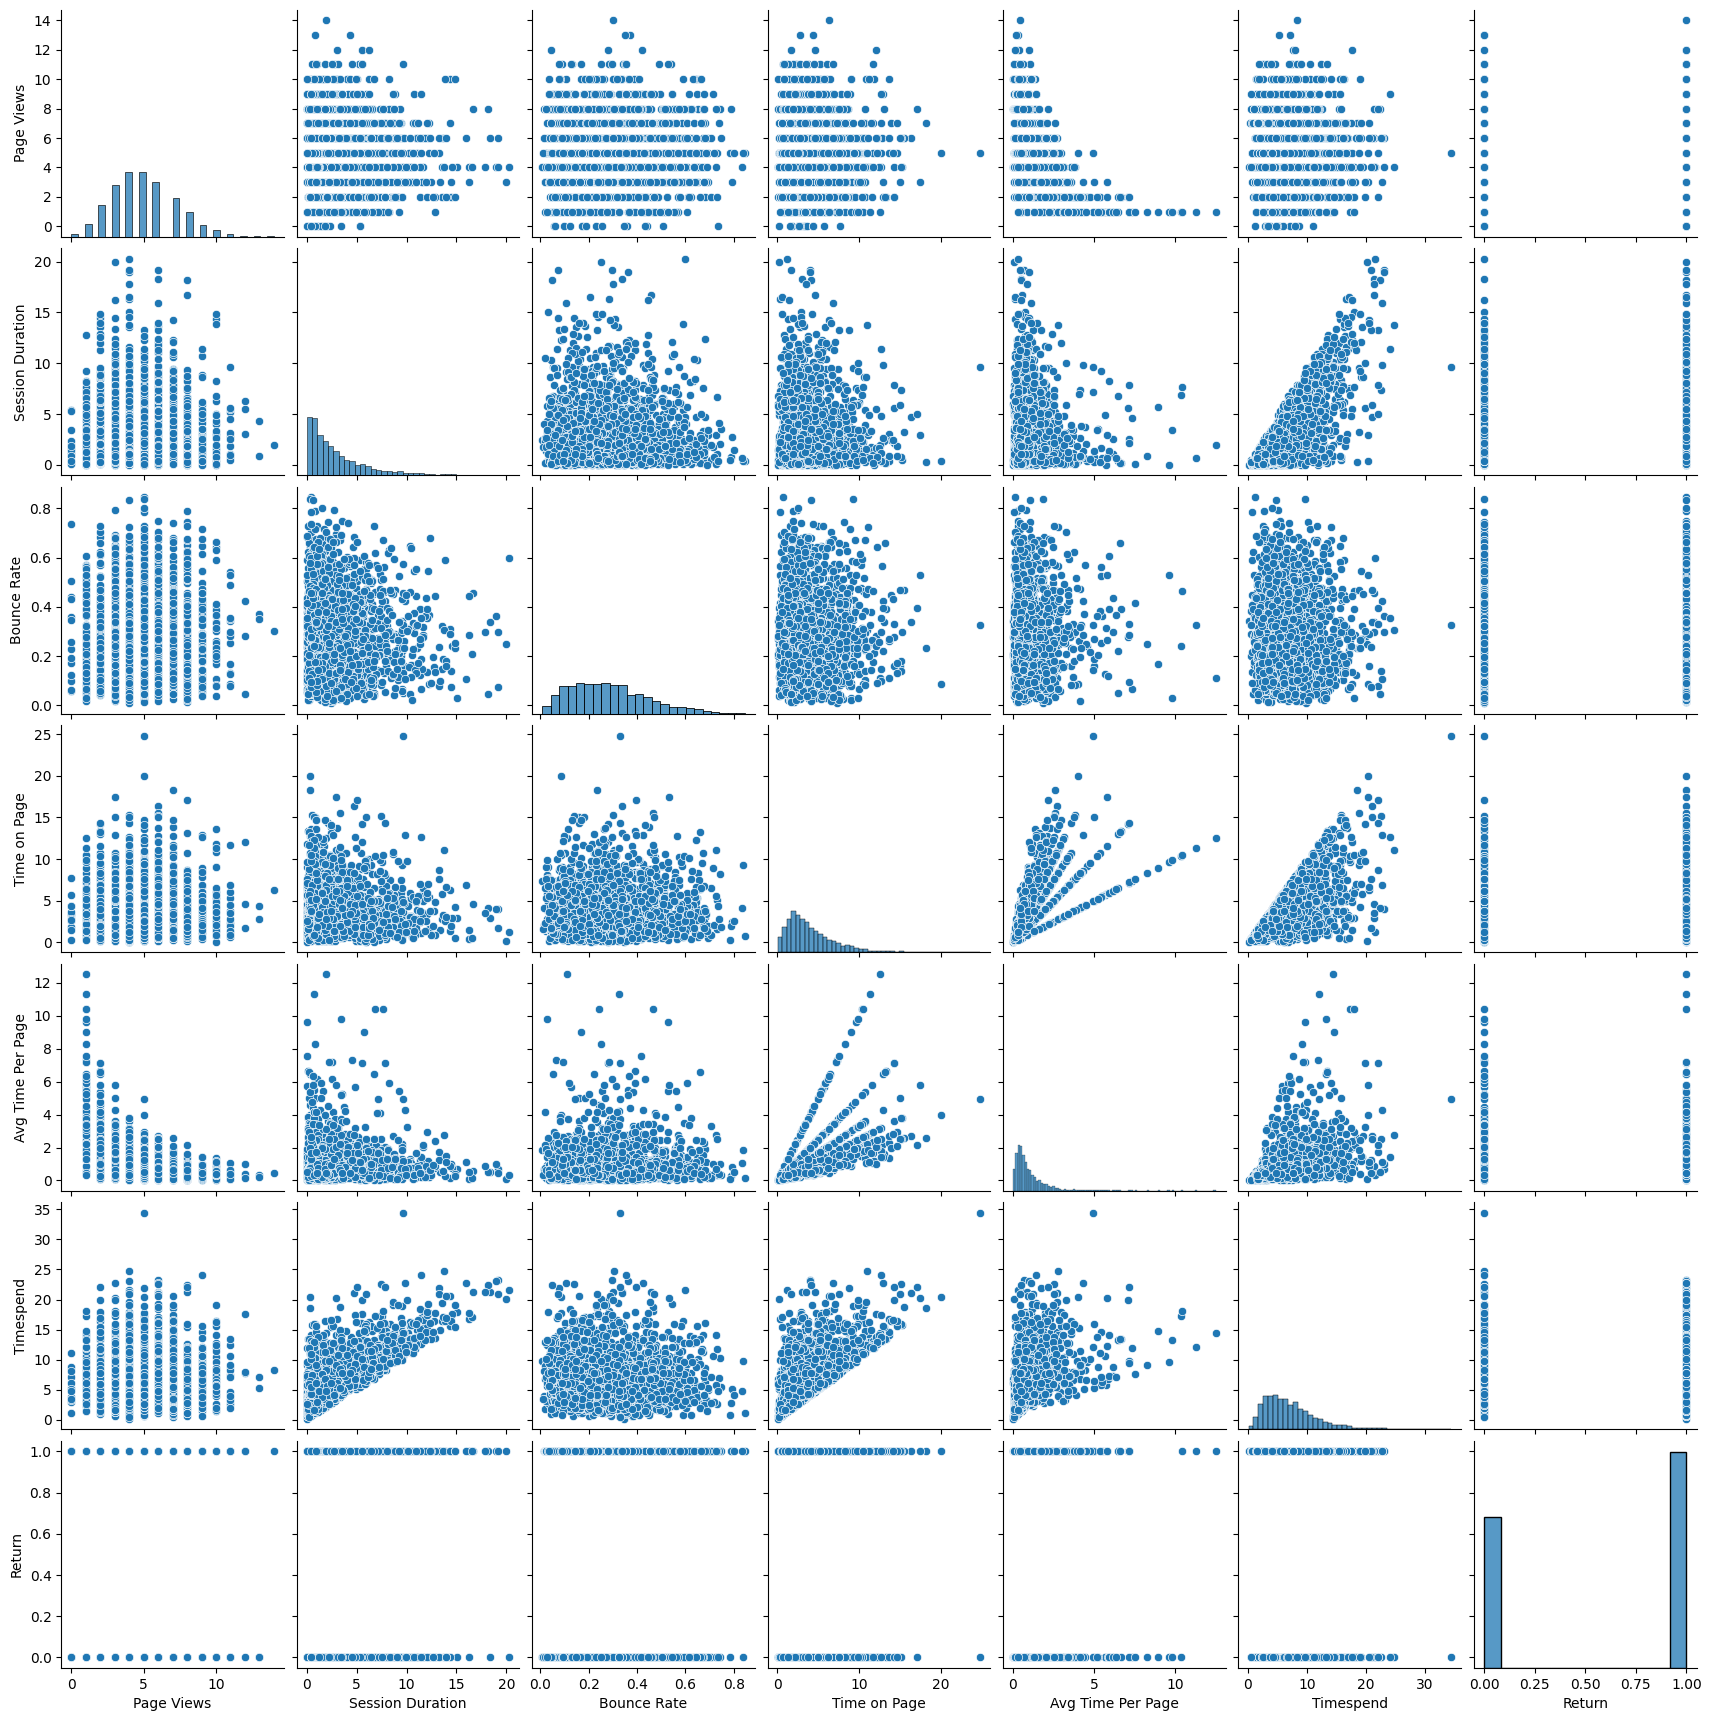

In [21]:
sns.pairplot(df)

In [31]:
df.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Avg Time Per Page,Timespend,Return
0,5,11.051381,0.230652,Organic,3.890460,0.778092,14.941841,1
1,4,3.429316,0.391001,Social,8.478174,2.119544,11.907490,0
2,4,1.621052,0.397986,Organic,9.636170,2.409042,11.257222,1
3,5,3.629279,0.180458,Organic,2.071925,0.414385,5.701204,1
4,5,4.235843,0.291541,Paid,1.960654,0.392131,6.196497,1


In [5]:
#step1--split the data 
X = df.drop("Return", axis=1)
y = df["Return"]

In [69]:
# np.isinf(X).sum()

In [6]:
#step--train/test/split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

In [7]:
X_train.shape

(1600, 7)

In [8]:
y_train.shape

(1600,)

In [ ]:
# # imputation transformer
# trf1 = ColumnTransformer([
#     ('impute_Avg Time Per Page',SimpleImputer(strategy='median'),[5]),
#     #('impute_embarked',SimpleImputer(strategy='most_frequent'),[6])
# ],remainder='passthrough')

In [10]:


class IQRCapper(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        self.columns = X.columns  # column names save karo
        
        self.Q1 = X.quantile(0.25)
        self.Q3 = X.quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        
        self.lower_bound = self.Q1 - 1.5 * self.IQR
        self.upper_bound = self.Q3 + 1.5 * self.IQR
        
        return self
    
    def transform(self, X):
        X_capped = X.copy()
        
        for col in self.columns:
            X_capped[col] = X_capped[col].clip(
                lower=self.lower_bound[col],
                upper=self.upper_bound[col]
            )
        
        return X_capped

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [12]:
trf2 = ColumnTransformer([
    ('iqr', IQRCapper(), num_cols),
], remainder='passthrough')

In [ ]:
trf3 = ColumnTransformer([
    ('log_income', FunctionTransformer(np.log1p), [1,2,4,5,6]),   # column index 3 need improvement code correct but information wrong 
    ('sqrt_age', FunctionTransformer(np.sqrt), [2])
], remainder='passthrough')

In [ ]:
# one hot encoding
trf4 = ColumnTransformer([
    ('ohe_Traffic_Source',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[3])
],remainder='passthrough')